# Survival analysis

Many clinical questions are about time: how long patients survive after ICU admission, and how quickly complications develop during the stay.
Survival analysis answers them while accounting for patients whose event was not observed during follow-up, which is known as censoring.

This tutorial uses two datasets.
The MIMIC-II IAC cohort follows 1,776 ICU patients for up to two years after admission and records whether and when they died, which long-term mortality questions need.
The hourly time series of the first 48 hours of 11,988 ICU stays of the PhysioNet 2012 challenge {cite}`silva2012predicting` {cite}`goldberger2000physiobank` hold events during the stay, from which ehrapy derives the time to the event directly.
We estimate survival curves and compare groups, handle competing events, adjust for confounders with Cox and accelerated failure time models, and analyse the time to hypotension in the time series.

## Environment setup

In [1]:
import warnings

warnings.filterwarnings("ignore")

import ehrapy as ep
import ehrdata as ed
import numpy as np
from lifelines.statistics import proportional_hazard_test

ep.settings.verbosity = "error"

In [2]:
%matplotlib inline

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
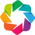

In [3]:
import holoviews as hv

hv.extension("bokeh")

## Two-year mortality after ICU admission

The [MIMIC-II IAC dataset](https://physionet.org/content/mimic2-iaccd/1.0/) holds one row of static information per patient.
`mort_day_censored` is the number of days from ICU admission to death or to the end of follow-up, and `censor_flg` is 1 for patients who died and 0 for censored patients.
We move the service unit, a categorical variable, to `obs`.

In [4]:
edata = ed.dt.mimic_2()
ed.move_to_obs(edata, ["service_unit"])
edata

EHRData object with n_obs × n_vars × n_t = 1776 × 45 × 1
    obs: 'service_unit'
    shape of .X: (1776, 45)

### Kaplan-Meier curves

{func}`~ehrapy.tools.kaplan_meier` estimates the probability of surviving beyond every time point.
Censored patients count as at risk until they leave follow-up, so they contribute information without being counted as survivors or deaths.
We fit one curve per service unit and compare the medical with the surgical ICU with {func}`~ehrapy.tools.test_kmf_logrank`.

In [5]:
kmfs = [
    ep.tl.kaplan_meier(
        edata[edata.obs["service_unit"] == unit], duration_col="mort_day_censored", event_col="censor_flg", label=unit
    )
    for unit in ["FICU", "MICU", "SICU"]
]
print(f"Log-rank p-value MICU vs SICU: {ep.tl.test_kmf_logrank(kmfs[1], kmfs[2]).p_value:.4f}")
ep.pl.kaplan_meier(
    kmfs,
    xlim=(0, 730),
    ylim=(0.5, 1),
    xlabel="Days since ICU admission",
    ylabel="Survival",
    display_survival_statistics=True,
)

Log-rank p-value MICU vs SICU: 0.0014


<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W

:Layout
   .Overlay.I :Overlay
      .Area.I     :Area   [x]   (y,y2)
      .Curve.FICU :Curve   [Time]   (Survival)
      .Area.II    :Area   [x]   (y,y2)
      .Curve.MICU :Curve   [Time]   (Survival)
      .Area.III   :Area   [x]   (y,y2)
      .Curve.SICU :Curve   [Time]   (Survival)
   .Table.I   :Table   [Group,0,81,162,243,324,406,487,568,649,730]

Two years after admission, 67% of patients from the medical ICU (MICU) are alive, compared to 75% from the surgical ICU (SICU) and 82% of the 62 patients from the FICU.
Most deaths happen in the first weeks, after which the curves separate only slowly.
The log-rank test tells us that the MICU and SICU curves differ, but not why: MICU patients are older and more often have atrial fibrillation.

:::{warning}
Kaplan-Meier assumes that censoring is unrelated to the risk of the event.
If patients leave follow-up because they are too sick or transferred to hospice, survival is overestimated.
:::

:::{admonition} Immortal time bias
:class: warning
Groups must be defined by information available at time zero.
This cohort was assembled to study arterial lines (`aline_flg`), but patients who received one during the stay had to survive until it was placed, which flatters their survival.
Start follow-up at the treatment decision, use a landmark time, or model the treatment as a time-varying covariate instead.
:::

### Competing events

`hosp_exp_flg` is 1 for the 244 patients who died in hospital.
Every other patient was discharged alive and can no longer die in hospital, so discharge is a competing event and not censoring.
We encode in-hospital death as 1 and discharge alive as 2 in `hospital_outcome` and pass `event_of_interest` to {func}`~ehrapy.tools.kaplan_meier`, which then estimates the cumulative incidence of every event with the Aalen-Johansen estimator.

In [6]:
died_in_hospital = ep.get.obs_df(edata, keys=["hosp_exp_flg"])["hosp_exp_flg"].astype(int)
edata.obs["hospital_outcome"] = np.where(died_in_hospital == 1, 1, 2)
ajfs = [
    ep.tl.kaplan_meier(
        edata, duration_col="hospital_los_day", event_col="hospital_outcome", event_of_interest=event, label=label
    )
    for event, label in [(1, "died in hospital"), (2, "discharged alive")]
]
naive = ep.tl.kaplan_meier(edata, duration_col="hospital_los_day", event_col="hosp_exp_flg")
print(f"In-hospital deaths: {died_in_hospital.mean():.1%}")
print(f"Cumulative incidence: {ajfs[0].cumulative_density_.iloc[-1, 0]:.1%}")
print(f"1 - Kaplan-Meier: {1 - naive.survival_function_.iloc[-1, 0]:.1%}")

In-hospital deaths: 13.7%
Cumulative incidence: 13.7%
1 - Kaplan-Meier: 51.9%


In [7]:
ep.pl.kaplan_meier(ajfs, xlim=(0, 60), xlabel="Days since hospital admission", ylabel="Cumulative incidence")

:Overlay
   .Area.I                 :Area   [x]   (y,y2)
   .Curve.Died_in_hospital :Curve   [Time]   (Cumulative incidence)
   .Area.II                :Area   [x]   (y,y2)
   .Curve.Discharged_alive :Curve   [Time]   (Cumulative incidence)

The cumulative incidence of in-hospital death reaches 13.7%, the share of patients who died in hospital.
One minus the Kaplan-Meier estimate treats discharged patients as if they could still die in hospital later and reports 52%, almost four times as much.

:::{important}
With competing events, one minus Kaplan-Meier overestimates the probability of the event.
Pass `event_of_interest` whenever another event, such as death or discharge, prevents the event of interest.
:::

### Cox proportional hazards model

{func}`~ehrapy.tools.cox_ph` models the hazard, the instantaneous risk of death among patients still alive, as a baseline hazard multiplied by the exponential of a linear combination of covariates.
The exponentiated coefficients are hazard ratios, adjusted for all other covariates in the `formula`.

In [8]:
cph = ep.tl.cox_ph(
    edata,
    duration_col="mort_day_censored",
    event_col="censor_flg",
    formula="age + gender_num + sapsi_first + afib_flg + service_unit",
)
cph.summary[["exp(coef)", "exp(coef) lower 95%", "exp(coef) upper 95%", "p"]]

,exp(coef),exp(coef) lower 95%,exp(coef) upper 95%,p
covariate,,,,
age,1.043629,1.037119,1.050179,8.226322e-41
gender_num,1.134847,0.941433,1.367996,1.845408e-01
sapsi_first,1.065229,1.039943,1.091131,2.534292e-07
afib_flg,1.509844,1.207800,1.887422,2.970981e-04
service_unit[T.MICU],1.405698,0.765905,2.579937,2.717056e-01
service_unit[T.SICU],1.161490,0.633362,2.129994,6.284937e-01


Every year of age increases the hazard of death by 4%, every point of the SAPS-I severity score at admission by 7%, and atrial fibrillation by 51%.
After adjustment for age, severity and atrial fibrillation, the service units no longer differ significantly.

:::{important}
The Cox model assumes that hazard ratios stay constant over time.
Test this assumption for every covariate with `proportional_hazard_test` from lifelines on the data the model was fitted on.
:::

In [9]:
covariates = ["age", "gender_num", "sapsi_first", "afib_flg", "service_unit"]
model_data = ep.get.obs_df(edata, keys=["mort_day_censored", "censor_flg", *covariates]).infer_objects().dropna()
proportional_hazard_test(cph, model_data, time_transform="rank").summary

,test_statistic,p,-log2(p)
afib_flg,0.434198,5.099360e-01,0.971612
age,0.587322,4.434567e-01,1.173135
gender_num,0.457383,4.988496e-01,1.003323
sapsi_first,28.611260,8.846627e-08,23.430297
service_unit[T.MICU],1.067309,3.015542e-01,1.729511
service_unit[T.SICU],3.923703,4.760992e-02,4.392594


The SAPS-I score clearly violates the assumption, and the SICU indicator marginally.
Severity at admission matters most for early deaths and less for deaths months later, so the hazard ratio of SAPS-I is therefore an average over time.

:::{admonition} What if hazards are not proportional?
:class: tip
Stratify by a categorical covariate that violates the assumption with `strata=`, which gives every stratum its own baseline hazard.
For continuous covariates, stratify by categories of it, add an interaction with time, or use an accelerated failure time model.
:::

### Adjusted survival curves

The Kaplan-Meier curves above mix the effect of the service unit with differences in age and severity.
{func}`~ehrapy.tools.cox_ph_adjusted_curves` instead assigns every patient to every service unit in turn and averages the predicted survival curves, so the curves differ only by the service unit.

In [10]:
ep.tl.cox_ph_adjusted_curves(
    edata,
    cph=cph,
    strata="service_unit",
    duration_col="mort_day_censored",
    event_col="censor_flg",
    times=np.linspace(0, 730, 100),
)
ep.pl.cox_ph_adjusted_curves(
    edata, title="Adjusted survival by service unit", xlabel="Days since ICU admission", ylabel="Adjusted survival"
)

:Overlay
   .Curve.SICU :Curve   [time]   (survival)
   .Area.I     :Area   [time]   (survival_lower,survival_upper)
   .Curve.MICU :Curve   [time]   (survival)
   .Area.II    :Area   [time]   (survival_lower,survival_upper)
   .Curve.FICU :Curve   [time]   (survival)
   .Area.III   :Area   [time]   (survival_lower,survival_upper)

After adjustment, two-year survival differs by 6 percentage points between the FICU and the MICU, compared to 15 percentage points between their Kaplan-Meier curves.
Most of the higher mortality in the medical ICU is explained by its older and sicker patients.

### Accelerated failure time models

Accelerated failure time (AFT) models assume a distribution for the survival time and model how covariates stretch or shrink it.
Their exponentiated coefficients are time ratios: a time ratio of 0.5 halves the expected survival time.
We fit {func}`~ehrapy.tools.weibull_aft` and {func}`~ehrapy.tools.log_logistic_aft` with the same covariates and compare their fit with the Akaike information criterion (AIC).

In [11]:
formula = "age + gender_num + sapsi_first + afib_flg + service_unit"
weibull = ep.tl.weibull_aft(edata, "mort_day_censored", "censor_flg", formula=formula, model_ancillary=False)
log_logistic = ep.tl.log_logistic_aft(edata, "mort_day_censored", event_col="censor_flg", formula=formula)
print(f"AIC Weibull: {weibull.AIC_:.0f}, log-logistic: {log_logistic.AIC_:.0f}")
log_logistic.summary.loc["alpha_", ["exp(coef)", "p"]]

AIC Weibull: 6462, log-logistic: 6417


,exp(coef),p
covariate,,
Intercept,1.952189e+09,2.600413e-62
age,8.849322e-01,3.692068e-33
gender_num,6.748259e-01,1.846947e-01
sapsi_first,7.734979e-01,4.006267e-10
afib_flg,2.127283e-01,4.566706e-05
service_unit[T.MICU],2.933578e-01,1.892247e-01
service_unit[T.SICU],5.367741e-01,5.035781e-01


The log-logistic model fits better, as its hazard can rise and fall, while the Weibull hazard can only rise or fall.
Atrial fibrillation shortens the median survival time about fivefold, and every year of age by 12%.

:::{admonition} Cox or AFT?
:class: tip
Use the Cox model by default, since it makes no assumption about the shape of the baseline hazard.
Use an AFT model when hazards are not proportional, when time ratios are easier to communicate than hazard ratios, or to predict survival times beyond the follow-up.
:::

### Regression for a fixed time horizon

If every patient is followed through a fixed time horizon, such as 28 days, the outcome is binary and needs no survival model.
{func}`~ehrapy.tools.glm` fits a logistic regression of 28-day mortality, whose exponentiated coefficients are odds ratios.

In [12]:
glm = ep.tl.glm(
    edata,
    formula="day_28_flg ~ age + sapsi_first + afib_flg + service_unit",
    family="Binomial",
    missing="drop",
    as_continuous=["day_28_flg", "age", "sapsi_first", "afib_flg"],
)
np.exp(glm.fit().params)

Intercept               0.000278
service_unit[T.MICU]    3.950864
service_unit[T.SICU]    3.341968
age                     1.043848
sapsi_first             1.165892
afib_flg                1.865054
dtype: float64

The odds ratios point in the same direction as the hazard ratios, but logistic regression discards when patients died and cannot use patients who were lost to follow-up before 28 days.

:::{seealso}
{func}`~ehrapy.tools.ols` fits linear regressions of continuous outcomes in the same way, and {func}`~ehrapy.plot.ols` plots their fits.
:::

## Time to hypotension during the ICU stay

The PhysioNet 2012 data holds 37 variables recorded hourly over the first 48 hours, so `.X` has the shape patients × variables × hours.
Survival functions in ehrapy derive the time to an event from such longitudinal data.

In [13]:
edata = ed.dt.physionet2012()
edata.tem["interval_start_offset"] = edata.tem["time_value"]

:::{note}
The survival functions read the time of every timepoint from `tem["interval_start_offset"]`.
We set it to `tem["time_value"]`, the hours since ICU admission, so that durations are in hours.
:::

We define hypotension as a mean arterial pressure (`MAP`) below 65 mmHg.
The new variable is 1 in every hour with hypotension, 0 in every hour without and missing where `MAP` was not measured.

In [14]:
hypotension = edata[:, ["MAP"]].copy()
hypotension.X = np.where(np.isnan(hypotension.X), np.nan, hypotension.X < 65)
hypotension.var_names = ["hypotension"]

With such a variable as `event_col` and no `duration_col`, {func}`~ehrapy.tools.kaplan_meier` takes the hour of the first 1 as the time of the event and censors patients without hypotension at their last `MAP` measurement.

In [15]:
kmfs = [
    ep.tl.kaplan_meier(hypotension[hypotension.obs["ICUType"] == icu_type], event_col="hypotension", label=icu_type)
    for icu_type in hypotension.obs["ICUType"].cat.categories
]
print(f"Log-rank p-value medical vs surgical: {ep.tl.test_kmf_logrank(kmfs[2], kmfs[3]).p_value:.1e}")
ep.pl.kaplan_meier(kmfs, xlabel="Hours since ICU admission", ylabel="Free of hypotension")

Log-rank p-value medical vs surgical: 1.7e-07


:Overlay
   .Area.I                         :Area   [x]   (y,y2)
   .Curve.Coronary_care            :Curve   [Time]   (Survival)
   .Area.II                        :Area   [x]   (y,y2)
   .Curve.Cardiac_surgery_recovery :Curve   [Time]   (Survival)
   .Area.III                       :Area   [x]   (y,y2)
   .Curve.Medical                  :Curve   [Time]   (Survival)
   .Area.IV                        :Area   [x]   (y,y2)
   .Curve.Surgical                 :Curve   [Time]   (Survival)

Half of the patients after cardiac surgery become hypotensive within 8 hours, compared to 21 to 28 hours in the other ICUs.
By hour 48, 26% to 43% of patients in the other ICUs remain free of hypotension, compared to 11% after cardiac surgery.

:::{warning}
`MAP` is measured invasively through an arterial line, which is often removed once a patient is stable.
Censoring at the last measurement is then informative, and the curves underestimate how many patients stay free of hypotension.
:::

{func}`~ehrapy.tools.nelson_aalen` estimates the cumulative hazard, and its smoothed differences show how the hazard changes over time.

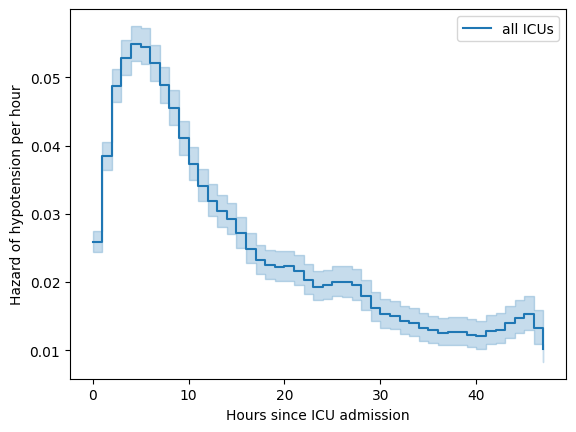

In [16]:
naf = ep.tl.nelson_aalen(hypotension, event_col="hypotension", label="all ICUs")
ax = naf.plot_hazard(bandwidth=3)
ax.set(xlabel="Hours since ICU admission", ylabel="Hazard of hypotension per hour");

The hazard of hypotension peaks 5 hours after admission at about 5% per hour and falls below 2% per hour on the second day.
Cox and AFT models accept the same longitudinal `event_col`, with covariates from `obs` or variables of the time series, which are taken at their first measured value.

In [17]:
cph = ep.tl.cox_ph(hypotension, event_col="hypotension", formula="Age + SOFA + ICUType")
cph.summary[["exp(coef)", "exp(coef) lower 95%", "exp(coef) upper 95%", "p"]]

,exp(coef),exp(coef) lower 95%,exp(coef) upper 95%,p
covariate,,,,
Age,1.015901,1.014103,1.017702,3.118730e-68
SOFA,1.088939,1.081189,1.096745,6.751456e-121
ICUType[T.cardiac surgery recovery],1.518073,1.391999,1.655565,3.846840e-21
ICUType[T.medical],0.839204,0.764466,0.921249,2.300369e-04
ICUType[T.surgical],0.835851,0.763534,0.915018,1.029609e-04


Every point of the SOFA score increases the hazard of hypotension by 9% and every year of age by 1.6%.
After adjustment, patients after cardiac surgery still have a 52% higher hazard than patients in the coronary care unit, which reflects the expected hypotension after cardiopulmonary bypass.

## Conclusion

Kaplan-Meier curves and log-rank tests describe and compare survival in the presence of censoring, and the Aalen-Johansen estimator replaces one minus Kaplan-Meier when competing events prevent the event of interest.
Cox models estimate adjusted hazard ratios under the proportional hazards assumption, which we tested, and adjusted survival curves showed that the higher mortality of the medical ICU is largely explained by its patients.
AFT models offer time ratios when hazards are not proportional.
All of these functions derive the time to an event directly from longitudinal data such as the hourly PhysioNet 2012 time series.